# 地形增强算法验证

本 Notebook 分两步验证：

- **数据预处理**：将官方投影坐标样例映射为当前实现可读的 `lat/lon` 六维输入。
- **结果对比**：读取原方法结果、修改后算法结果和 KGO，做数值统计与可视化对比。

验证划分为两套方案：

1. **方案一（投影坐标 / 维名重命名）**：预处理仅重命名投影维；写出 `cli_input/` 供 CLI；结果写入 `cli_output/`；KGO 与原方法结果直接读官方投影 nc。
2. **方案二（经纬坐标 / 重网格）**：预处理阶段进行投影转经纬以及重网格处理；修改后算法与原方法均使用转换后数据。


## 环境准备

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from matplotlib.colors import BoundaryNorm, ListedColormap

plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "SimSun", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

PACKAGE_ROOT = Path.cwd().resolve().parents[0]
PROJECT_ROOT = PACKAGE_ROOT.parent
DATA_DIR = PACKAGE_ROOT / "test_data" / "orographic_enhancement_data"
CLI_INPUT_DIR = DATA_DIR / "cli_input"
CLI_OUTPUT_DIR = DATA_DIR / "cli_output"
PPT_FIG_DIR = PACKAGE_ROOT / "nbs" / "_ppt_figures_scheme1"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from orographic_enhancement.src.orographic_enhancement import MetaOrographicEnhancement

print(f"包根目录: {PACKAGE_ROOT}")
print(f"数据目录: {DATA_DIR}")


d:\workspace\improver\venv\Lib\site-packages\meteva_base\basicdata\const.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


包根目录: D:\workspace\improver\orographic_enhancement
数据目录: D:\workspace\improver\orographic_enhancement\test_data\orographic_enhancement_data


In [2]:
# 离散分级降水色标（单位：mm hr-1）
# 使用离散分级降水色标，深蓝色表示 >50
PRECIP_CLASS_BOUNDS = (
    0.0,
    0.1,
    2.5,
    5.0,
    10.0,
    25.0,
    50.0,
)
PRECIP_CLASS_RGB = (
    (255, 255, 255),  # [0, 0.1)
    (210, 245, 160),  # [0.1, 2.5)
    (150, 220, 95),   # [2.5, 5)
    (70, 185, 65),    # [5, 10)
    (35, 155, 40),    # [10, 25)
    (96, 184, 255),   # [25, 50)
)
precip_cmap = ListedColormap(np.array(PRECIP_CLASS_RGB, dtype=float) / 255.0)
precip_cmap.set_over((0.0, 0.0, 1.0))  # >50 使用深蓝色
main_norm = BoundaryNorm(PRECIP_CLASS_BOUNDS, precip_cmap.N, clip=False)

# 色标刻度：显示降水分级边界（0.1, 2.5, 5, 10, 25, 50）
PRECIP_CBAR_TICKS = (0.1, 2.5, 5.0, 10.0, 25.0, 50.0)


def _format_precip_cbar_tick(value: float) -> str:
    if value < 1.0:
        return f"{value:.1f}"
    if float(value).is_integer():
        return str(int(value))
    return f"{value:.1f}"


def add_precip_colorbar(fig, axes, mesh=None, *, label: str = "mm hr-1"):
    """为离散分级降水图添加统一色标。"""
    cbar = fig.colorbar(
        mesh if mesh is not None else plt.cm.ScalarMappable(norm=main_norm, cmap=precip_cmap),
        ax=axes,
        extend="max",
        boundaries=list(PRECIP_CLASS_BOUNDS),
        ticks=list(PRECIP_CBAR_TICKS),
        shrink=0.8,
    )
    cbar.set_ticklabels([_format_precip_cbar_tick(t) for t in PRECIP_CBAR_TICKS])
    cbar.set_label(label)
    return cbar


# 地形增量单位转换：m s-1 -> mm hr-1
MPS_TO_MMHR = 3600.0 * 1000.0


## 方案一：投影坐标输入

### 1. 数据预处理

In [3]:
def load_primary_dataarray(nc_path: Path, var_name: str) -> xr.DataArray:
    """读取 netCDF 主变量，并写入 grid_mapping_attrs。"""
    ds = xr.open_dataset(nc_path, decode_timedelta=False)
    try:
        if var_name not in ds.data_vars:
            raise ValueError(f"变量 {var_name} 不存在: {nc_path}")
        data = ds[var_name].load()

        grid_mapping_name = data.attrs.get("grid_mapping")
        if isinstance(grid_mapping_name, str) and grid_mapping_name in ds.variables:
            mapping_attrs_raw = dict(ds[grid_mapping_name].attrs)
            mapping_attrs_json_ready = {}
            for key, value in mapping_attrs_raw.items():
                if isinstance(value, np.ndarray):
                    mapping_attrs_json_ready[key] = value.tolist()
                elif isinstance(value, np.generic):
                    mapping_attrs_json_ready[key] = value.item()
                else:
                    mapping_attrs_json_ready[key] = value
            data.attrs["grid_mapping_attrs"] = json.dumps(
                mapping_attrs_json_ready, ensure_ascii=False
            )
        return data
    finally:
        ds.close()


def _extract_projected_spatial(da: xr.DataArray) -> xr.DataArray:
    """提取投影空间场；保留 level，将 height/投影维重命名为 level/lat/lon。"""
    arr = da
    rename_map = {}
    if "height" in arr.dims:
        rename_map["height"] = "level"
    if "projection_y_coordinate" in arr.dims:
        rename_map["projection_y_coordinate"] = "lat"
    if "projection_x_coordinate" in arr.dims:
        rename_map["projection_x_coordinate"] = "lon"
    if rename_map:
        arr = arr.rename(rename_map)

    keep_dims = ("level", "lat", "lon")
    for dim in list(arr.dims):
        if dim not in keep_dims:
            arr = arr.isel({dim: 0}, drop=True)

    expected_order = [d for d in ("level", "lat", "lon") if d in arr.dims]
    if arr.dims != tuple(expected_order):
        arr = arr.transpose(*expected_order)
    return arr


def _build_meb6d_from_spatial(
    spatial: xr.DataArray,
    *,
    name: str,
    extra_attrs: dict | None = None,
) -> xr.DataArray:
    """由二维/三维（含 level）lat/lon 场构造六维 meb 网格。"""
    units = str(spatial.attrs.get("units", "1"))
    if "level" in spatial.dims:
        level_values = spatial.coords["level"].values.astype(np.float32)
        values = spatial.values[np.newaxis, :, np.newaxis, np.newaxis, :, :].astype(np.float32)
    else:
        level_values = np.array([0.0], dtype=np.float32)
        values = spatial.values[np.newaxis, np.newaxis, np.newaxis, np.newaxis, :, :].astype(np.float32)

    attrs = {
        "units": units,
        "model": None,
        "dtime_units": "hour",
        "level_type": "height",
        "time_type": "UT",
        "time_bounds": [0, 0],
    }
    if extra_attrs:
        attrs.update(extra_attrs)

    grid_mapping_attrs = spatial.attrs.get("grid_mapping_attrs")
    if isinstance(grid_mapping_attrs, str) and grid_mapping_attrs.strip():
        attrs["grid_mapping_attrs"] = grid_mapping_attrs

    return xr.DataArray(
        values,
        dims=("member", "level", "time", "dtime", "lat", "lon"),
        coords={
            "member": np.array(["data0"], dtype=object),
            "level": level_values,
            "time": np.array([np.datetime64("1970-01-01T00:00:00")], dtype="datetime64[ns]"),
            "dtime": np.array([0], dtype=np.int32),
            "lat": spatial.coords["lat"].copy(deep=True),
            "lon": spatial.coords["lon"].copy(deep=True),
        },
        attrs=attrs,
        name=name,
    )


def build_meb6d_from_projected(nc_path: Path, var_name: str) -> xr.DataArray:
    """由投影样例构造六维输入（仅维名重命名 + height->level）。"""
    spatial = _extract_projected_spatial(load_primary_dataarray(nc_path, var_name))
    return _build_meb6d_from_spatial(spatial, name=var_name)


def save_meb6d_to_nc(data: xr.DataArray, dst_path: Path) -> None:
    """将内存中的六维 meb 数据写出为 nc（供 CLI 读取）。"""
    normalized = data.copy(deep=True)
    normalized.attrs = {k: ("" if v is None else v) for k, v in dict(normalized.attrs).items()}
    dst_path.parent.mkdir(parents=True, exist_ok=True)
    normalized.to_dataset(name=normalized.name).to_netcdf(dst_path)


def to_2d_values(data: xr.DataArray) -> np.ndarray:
    """将 DataArray 统一提取为二维 numpy 数组（lat, lon）。"""
    arr = data
    if {"projection_y_coordinate", "projection_x_coordinate"}.issubset(set(arr.dims)):
        arr = _extract_projected_spatial(arr)
    else:
        for dim in list(arr.dims):
            if dim not in ("lat", "lon"):
                arr = arr.isel({dim: 0}, drop=True)
        if arr.dims != ("lat", "lon"):
            arr = arr.transpose("lat", "lon")
    return np.asarray(arr.values, dtype=np.float64)


def compare_stats(current: xr.DataArray, reference: xr.DataArray, tag: str):
    """对比两个二维场，计算平均绝对误差、最大绝对误差和均方根误差。"""
    c = to_2d_values(current)
    r = to_2d_values(reference)
    if c.shape != r.shape:
        raise ValueError(f"二维场形状不一致: current={c.shape}, reference={r.shape}")
    diff = c - r
    print(
        f"[{tag}] mean_abs={np.mean(np.abs(diff)):.8f}, "
        f"max_abs={np.max(np.abs(diff)):.8f}, rmse={np.sqrt(np.mean(diff**2)):.8f}"
    )
    return c, r, diff


def ensure_2d(data: xr.DataArray) -> xr.DataArray:
    result = data.squeeze(drop=True)
    if result.ndim != 2:
        raise ValueError(f"Expected a 2D field, got dims={result.dims}")
    return result


def to_plot_2d(data: xr.DataArray) -> xr.DataArray:
    candidate_pairs = [
        ("projection_y_coordinate", "projection_x_coordinate"),
        ("lat", "lon"),
    ]
    dims_set = set(data.dims)
    selected_pair = None
    for y_name, x_name in candidate_pairs:
        if y_name in dims_set and x_name in dims_set:
            selected_pair = (y_name, x_name)
            break
    if selected_pair is None:
        selected_pair = (data.dims[-2], data.dims[-1])
    spatial_dims = set(selected_pair)
    indexers = {dim: 0 for dim in data.dims if dim not in spatial_dims}
    reduced = data.isel(indexers, drop=True) if indexers else data
    return ensure_2d(reduced)


def align_spatial_to_reference(field: xr.DataArray, reference: xr.DataArray) -> xr.DataArray:
    """将场的空间坐标对齐到参考场，便于与 KGO/原算法同图对比。"""
    field2d = ensure_2d(to_plot_2d(field)).copy()
    ref2d = ensure_2d(to_plot_2d(reference)).copy()
    y_name, x_name = field2d.dims
    ry, rx = ref2d.dims
    if field2d.shape != ref2d.shape:
        raise ValueError(f"空间场形状不一致: field={field2d.shape}, reference={ref2d.shape}")

    y_f = np.asarray(field2d.coords[y_name].values, dtype=np.float64)
    y_r = np.asarray(ref2d.coords[ry].values, dtype=np.float64)
    x_f = np.asarray(field2d.coords[x_name].values, dtype=np.float64)
    x_r = np.asarray(ref2d.coords[rx].values, dtype=np.float64)
    aligned = field2d

    if np.allclose(y_f, y_r[::-1], rtol=0, atol=1.0):
        aligned = aligned.assign_coords({y_name: y_r})
    elif not np.allclose(y_f, y_r, rtol=0, atol=1.0):
        if np.allclose(y_f[::-1], y_r, rtol=0, atol=1.0):
            aligned = aligned.isel({y_name: slice(None, None, -1)}).assign_coords({y_name: y_r})
        else:
            raise ValueError(
                f"Y 坐标无法与参考场对齐: field=[{y_f[0]}, {y_f[-1]}], reference=[{y_r[0]}, {y_r[-1]}]"
            )

    if np.allclose(x_f, x_r[::-1], rtol=0, atol=1.0):
        aligned = aligned.assign_coords({x_name: x_r})
    elif not np.allclose(x_f, x_r, rtol=0, atol=1.0):
        if np.allclose(x_f[::-1], x_r, rtol=0, atol=1.0):
            aligned = aligned.isel({x_name: slice(None, None, -1)}).assign_coords({x_name: x_r})
        else:
            raise ValueError(
                f"X 坐标无法与参考场对齐: field=[{x_f[0]}, {x_f[-1]}], reference=[{x_r[0]}, {x_r[-1]}]"
            )

    return aligned.rename({y_name: ry, x_name: rx})


def orient_for_plot(data_2d: xr.DataArray) -> xr.DataArray:
    result = ensure_2d(data_2d).copy()
    y_name, x_name = result.dims
    y_vals = result.coords[y_name].values
    x_vals = result.coords[x_name].values
    if y_vals.size > 1 and y_vals[0] > y_vals[-1]:
        result = result.isel({y_name: slice(None, None, -1)})
    if x_vals.size > 1 and x_vals[0] > x_vals[-1]:
        result = result.isel({x_name: slice(None, None, -1)})
    return result


def plot_field(
    ax,
    data: xr.DataArray,
    title: str,
    *,
    reference: xr.DataArray | None = None,
    cmap=precip_cmap,
    norm=main_norm,
):
    plot_data = to_plot_2d(data)
    if reference is not None:
        plot_data = align_spatial_to_reference(plot_data, reference)
    else:
        plot_data = orient_for_plot(plot_data)
    y_name, x_name = plot_data.dims
    x_vals = plot_data.coords[x_name].values
    y_vals = plot_data.coords[y_name].values
    mesh = ax.pcolormesh(x_vals, y_vals, plot_data.values, shading="auto", cmap=cmap, norm=norm)
    ax.set_xlim(float(np.nanmin(x_vals)), float(np.nanmax(x_vals)))
    ax.set_ylim(float(np.nanmin(y_vals)), float(np.nanmax(y_vals)))
    ax.set_title(title)
    ax.set_xlabel(x_name)
    ax.set_ylabel(y_name)
    ax.set_aspect("equal")
    return mesh


def to_mmhr(data: xr.DataArray) -> xr.DataArray:
    result = ensure_2d(data).copy()
    result.values = result.values * MPS_TO_MMHR
    result.attrs["units"] = "mm hr-1"
    return result


def plot_precip_triplet(modified, kgo, original, *, title: str):
    fig, axes = plt.subplots(1, 3, figsize=(22, 6), constrained_layout=True)
    fig.suptitle(title, fontsize=14, y=1.02)
    plot_ref = to_plot_2d(kgo)
    plot_field(axes[0], to_mmhr(modified), "修改后算法", reference=plot_ref)
    plot_field(axes[1], to_mmhr(original), "原方法结果", reference=plot_ref)
    mesh = plot_field(axes[2], to_mmhr(kgo), "KGO 官方预期")
    add_precip_colorbar(fig, axes, mesh=mesh)
    plt.show()


def select_level_for_plot(data: xr.DataArray, level: float | None = 500.0) -> xr.DataArray:
    """从六维/三维场中选取指定高度层（米）用于绘图。"""
    if level is None or "level" not in data.dims:
        return data
    level_values = np.asarray(data.coords["level"].values, dtype=np.float64)
    if level_values.size == 1:
        return data.isel(level=0, drop=True)
    idx = int(np.argmin(np.abs(level_values - level)))
    return data.isel(level=idx, drop=True)


def prepare_plot_field(data: xr.DataArray, *, level: float | None = 500.0) -> xr.DataArray:
    return to_plot_2d(select_level_for_plot(data, level)).copy()


def apply_value_transform(data: xr.DataArray, transform) -> xr.DataArray:
    if transform is None:
        return data
    result = data.copy()
    result.values = transform(result.values)
    return result


def plot_scalar_field(
    ax,
    data: xr.DataArray,
    title: str,
    *,
    reference: xr.DataArray | None = None,
    cmap: str = "viridis",
    vmin=None,
    vmax=None,
    cbar_label: str | None = None,
):
    """绘制连续标量场（PPT 插图用，各子图自带色标）。"""
    plot_data = to_plot_2d(data)
    if reference is not None:
        plot_data = align_spatial_to_reference(plot_data, reference)
    else:
        plot_data = orient_for_plot(plot_data)
    y_name, x_name = plot_data.dims
    x_vals = plot_data.coords[x_name].values
    y_vals = plot_data.coords[y_name].values
    mesh = ax.pcolormesh(
        x_vals,
        y_vals,
        plot_data.values,
        shading="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_xlim(float(np.nanmin(x_vals)), float(np.nanmax(x_vals)))
    ax.set_ylim(float(np.nanmin(y_vals)), float(np.nanmax(y_vals)))
    ax.set_title(title, fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal")
    if cbar_label:
        cbar = plt.colorbar(mesh, ax=ax, shrink=0.85, pad=0.02)
        cbar.set_label(cbar_label, fontsize=9)
    return mesh



In [4]:
# 方案一：读原数据 -> 预处理 -> 写出 cli_input（供 CLI）；算法验证使用内存数据
temperature_meb = build_meb6d_from_projected(DATA_DIR / "temperature.nc", "air_temperature")
humidity_meb = build_meb6d_from_projected(DATA_DIR / "humidity.nc", "relative_humidity")
pressure_meb = build_meb6d_from_projected(DATA_DIR / "pressure.nc", "air_pressure")
wind_speed_meb = build_meb6d_from_projected(DATA_DIR / "wind_speed.nc", "wind_speed")
wind_direction_meb = build_meb6d_from_projected(DATA_DIR / "wind_direction.nc", "wind_from_direction")
topography_meb = build_meb6d_from_projected(DATA_DIR / "orography_uk-standard_1km.nc", "surface_altitude")

CLI_INPUT_DIR.mkdir(parents=True, exist_ok=True)
scheme1_cli_inputs = [
    ("temperature.nc", temperature_meb),
    ("humidity.nc", humidity_meb),
    ("pressure.nc", pressure_meb),
    ("wind_speed.nc", wind_speed_meb),
    ("wind_direction.nc", wind_direction_meb),
    ("orography_uk-standard_1km.nc", topography_meb),
]
for filename, data in scheme1_cli_inputs:
    save_meb6d_to_nc(data, CLI_INPUT_DIR / filename)
    print(f"写出: {CLI_INPUT_DIR / filename}")

print("方案一输入:", temperature_meb.dims, temperature_meb.shape)
print("方案一地形:", topography_meb.dims, topography_meb.shape)


写出: D:\workspace\improver\orographic_enhancement\test_data\orographic_enhancement_data\cli_input\temperature.nc
写出: D:\workspace\improver\orographic_enhancement\test_data\orographic_enhancement_data\cli_input\humidity.nc
写出: D:\workspace\improver\orographic_enhancement\test_data\orographic_enhancement_data\cli_input\pressure.nc
写出: D:\workspace\improver\orographic_enhancement\test_data\orographic_enhancement_data\cli_input\wind_speed.nc
写出: D:\workspace\improver\orographic_enhancement\test_data\orographic_enhancement_data\cli_input\wind_direction.nc
写出: D:\workspace\improver\orographic_enhancement\test_data\orographic_enhancement_data\cli_input\orography_uk-standard_1km.nc
方案一输入: ('member', 'level', 'time', 'dtime', 'lat', 'lon') (1, 5, 1, 1, 101, 101)
方案一地形: ('member', 'level', 'time', 'dtime', 'lat', 'lon') (1, 1, 1, 1, 199, 202)


### 1.1 输入数据

以 500 m 层展示气象输入；地形为全层场。

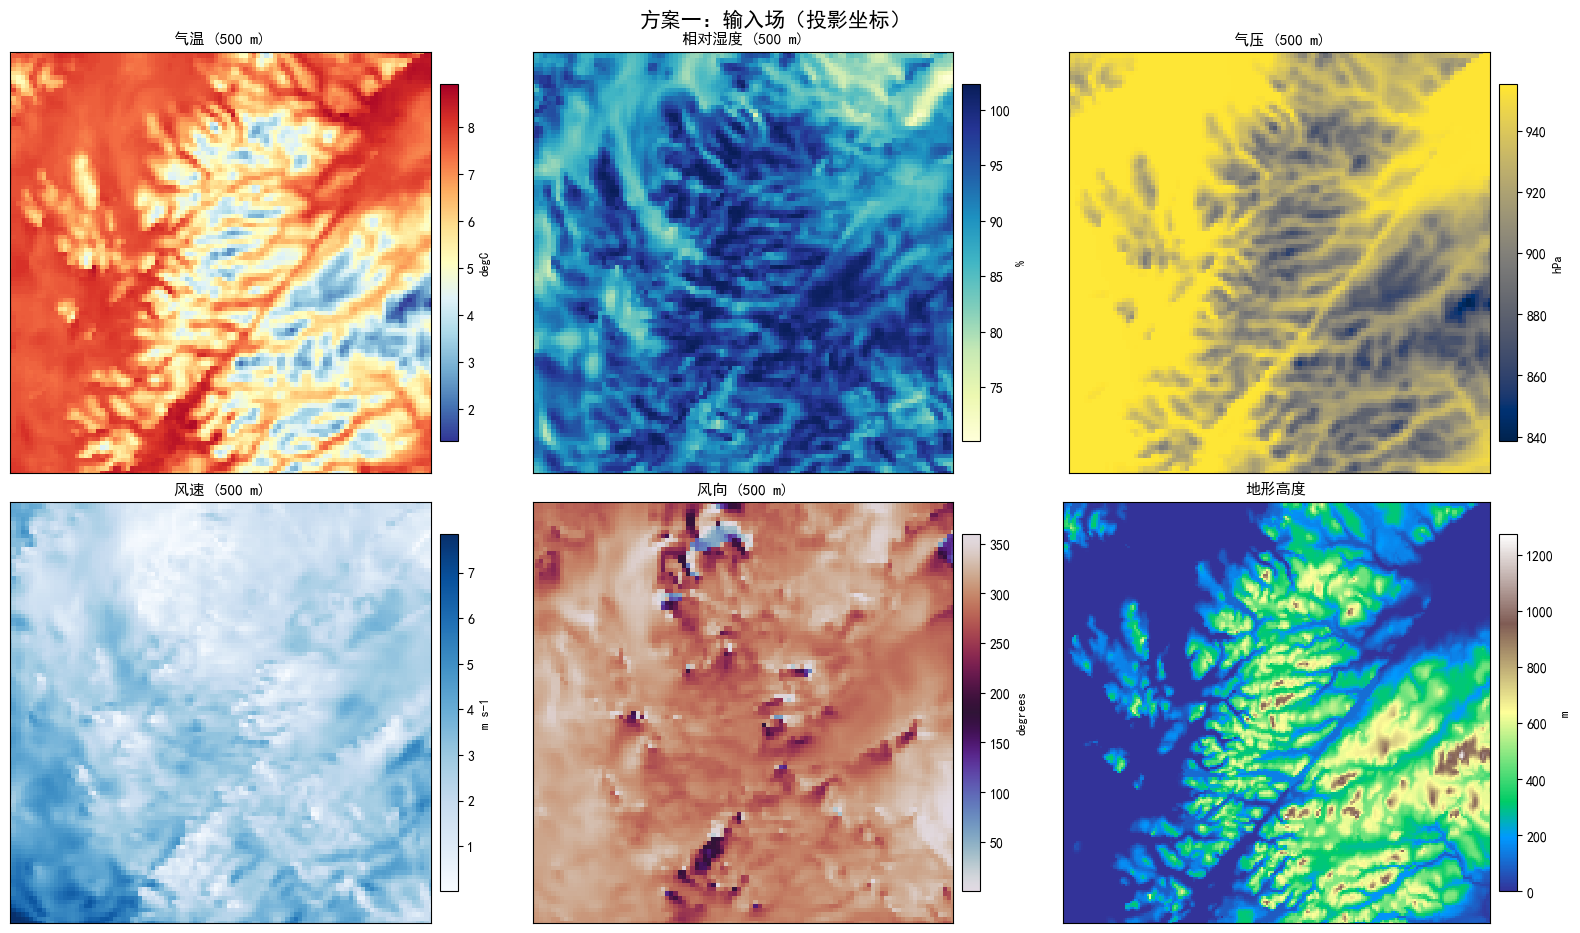

In [5]:
PLOT_LEVEL_M = 500.0
plot_ref_met = prepare_plot_field(temperature_meb, level=PLOT_LEVEL_M)

scheme1_input_specs = [
    (temperature_meb, f"气温 ({PLOT_LEVEL_M:.0f} m)", "RdYlBu_r", lambda v: v - 273.15, "degC", True),
    (humidity_meb, f"相对湿度 ({PLOT_LEVEL_M:.0f} m)", "YlGnBu", lambda v: v * 100.0, "%", True),
    (pressure_meb, f"气压 ({PLOT_LEVEL_M:.0f} m)", "cividis", lambda v: v / 100.0, "hPa", True),
    (wind_speed_meb, f"风速 ({PLOT_LEVEL_M:.0f} m)", "Blues", None, "m s-1", True),
    (wind_direction_meb, f"风向 ({PLOT_LEVEL_M:.0f} m)", "twilight", None, "degrees", True),
    (topography_meb, "地形高度", "terrain", None, "m", False),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)
fig.suptitle("方案一：输入场（投影坐标）", fontsize=15, y=1.02)

for ax, (field_meb, title, cmap, transform, unit, align_to_met) in zip(
    axes.ravel(), scheme1_input_specs, strict=True
):
    field_plot = prepare_plot_field(field_meb, level=PLOT_LEVEL_M)
    field_plot = apply_value_transform(field_plot, transform)
    ref = plot_ref_met if align_to_met else None
    plot_scalar_field(ax, field_plot, title, reference=ref, cmap=cmap, cbar_label=unit)

plt.show()



### 2. MetaOrographicEnhancement

=== 方案一：MetaOrographicEnhancement ===
[方案一 修改后-KGO] mean_abs=0.00000000, max_abs=0.00000056, rmse=0.00000001
[方案一 修改后-原算法] mean_abs=0.00000000, max_abs=0.00000056, rmse=0.00000001
[方案一 原算法-KGO] mean_abs=0.00000000, max_abs=0.00000000, rmse=0.00000000


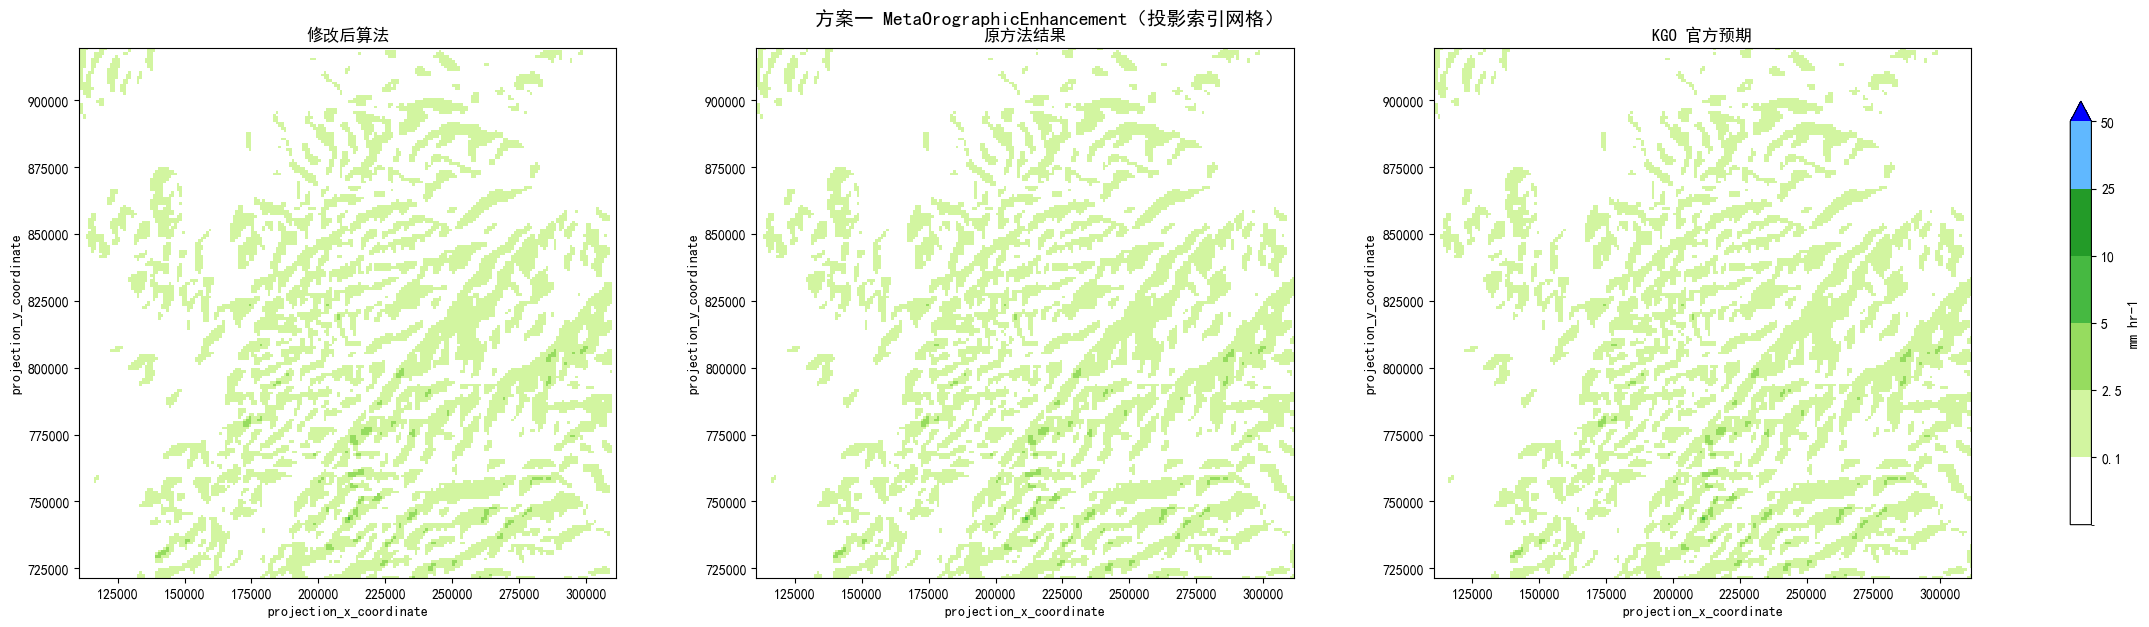

In [6]:
print("=== 方案一：MetaOrographicEnhancement ===")
plugin_s1 = MetaOrographicEnhancement()
migrated_s1 = plugin_s1(
    temperature_meb,
    humidity_meb,
    pressure_meb,
    wind_speed_meb,
    wind_direction_meb,
    topography_meb,
)
migrated_s1.name = "orographic_enhancement"

kgo_s1 = load_primary_dataarray(DATA_DIR / "kgo_hi_res.nc", "orographic_enhancement")
original_s1 = load_primary_dataarray(DATA_DIR / "original_algorithm_result.nc", "orographic_enhancement")

compare_stats(migrated_s1, kgo_s1, "方案一 修改后-KGO")
compare_stats(migrated_s1, original_s1, "方案一 修改后-原算法")
compare_stats(original_s1, kgo_s1, "方案一 原算法-KGO")
plot_precip_triplet(
    migrated_s1,
    kgo_s1,
    original_s1,
    title="方案一 MetaOrographicEnhancement（投影索引网格）",
)


### 2.1 修改后算法结果

单独展示修改后 MetaOrographicEnhancement 输出，使用与验证一致的离散降水色标。

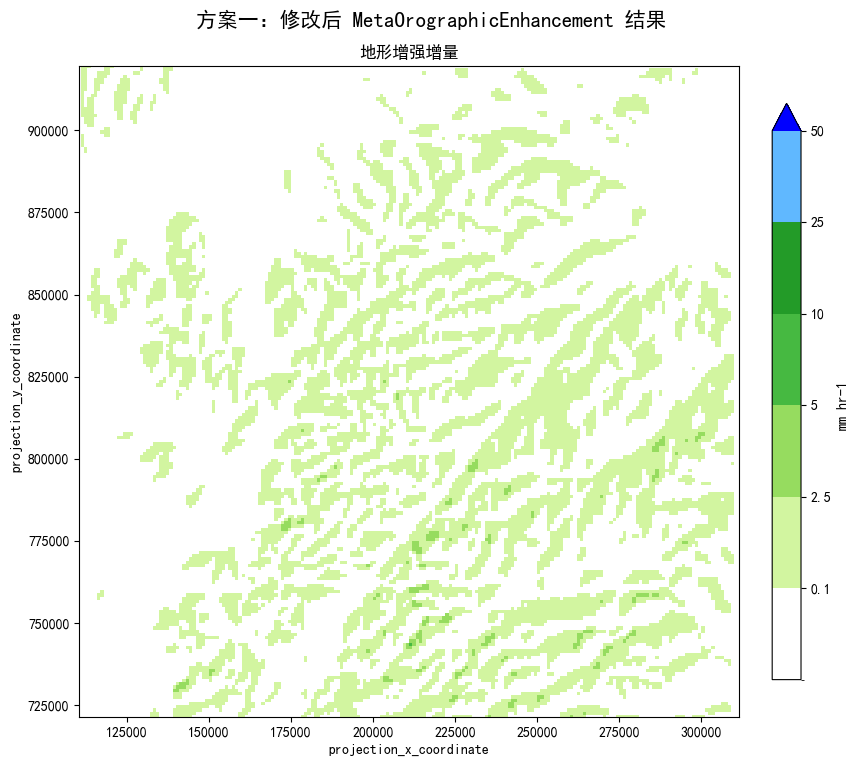

In [7]:
fig, ax = plt.subplots(figsize=(8.5, 7.5), constrained_layout=True)
plot_ref_oe = to_plot_2d(kgo_s1)
mesh = plot_field(
    ax,
    to_mmhr(migrated_s1),
    "地形增强增量",
    reference=plot_ref_oe,
)
add_precip_colorbar(fig, [ax], mesh=mesh)
fig.suptitle("方案一：修改后 MetaOrographicEnhancement 结果", fontsize=15, y=1.02)
plt.show()


### 3. ApplyOrographicEnhancement（方案一）

In [8]:
from datetime import datetime

try:
    import iris
    from cf_units import Unit
except Exception as exc:
    raise RuntimeError(f"当前环境缺少 iris/cf_units，无法运行原算法 ApplyOE 对比：{exc}") from exc

if str(PROJECT_ROOT / "improver-1.18.7") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "improver-1.18.7"))

from improver.nowcasting.utilities import ApplyOrographicEnhancement as OriginalApplyOrographicEnhancement
from orographic_enhancement.src.apply_orographic_enhancement import (
    ApplyOrographicEnhancement as MigratedApplyOrographicEnhancement,
)
from orographic_enhancement.src.utils._grid import _needs_regridding, _regrid_scalar_field


def harmonize_time_calendar_to_standard(cube):
    out = cube.copy()
    if out.coords("time"):
        t = out.coord("time").copy()
        time_dims = out.coord_dims("time")
        t.convert_units("seconds since 1970-01-01 00:00:00")
        t.units = Unit("seconds since 1970-01-01 00:00:00", calendar="standard")
        out.remove_coord("time")
        if len(time_dims) == 1:
            try:
                out.add_dim_coord(t, time_dims[0])
            except Exception:
                out.add_aux_coord(t, data_dims=time_dims)
        else:
            out.add_aux_coord(t)
    return out


def squeeze_cube_to_projected_2d(cube):
    out = cube.copy()
    y_name = "projection_y_coordinate"
    x_name = "projection_x_coordinate"
    y_dim = out.coord_dims(y_name)[0]
    x_dim = out.coord_dims(x_name)[0]
    indexer = [0] * out.ndim
    indexer[y_dim] = slice(None)
    indexer[x_dim] = slice(None)
    return out[tuple(indexer)]


def standardize_precip_cube_for_plugin(precip_cube, oe_cube):
    cube = precip_cube.copy()
    cube.rename("lwe_precipitation_rate")
    cube.units = "mm hr-1"
    if oe_cube.coords("time"):
        t = oe_cube.coord("time").copy()
        if t.ndim > 0:
            t = t[0]
        if cube.coords("time"):
            cube.remove_coord("time")
        cube.add_aux_coord(t)
    elif not cube.coords("time"):
        cube.add_aux_coord(
            iris.coords.AuxCoord(
                np.array([0.0], dtype=np.float64),
                standard_name="time",
                units=Unit("seconds since 1970-01-01 00:00:00", calendar="standard"),
            )
        )
    return cube


def _attach_grid_mapping_json(target: xr.DataArray, source: xr.DataArray) -> xr.DataArray:
    mapping_json = source.attrs.get("grid_mapping_attrs")
    if not isinstance(mapping_json, str) or not mapping_json.strip():
        return target
    result = target.copy()
    result.attrs["grid_mapping_attrs"] = mapping_json
    return result


def to_meb6d_for_apply(data_2d: xr.DataArray, name: str) -> xr.DataArray:
    d2 = to_plot_2d(data_2d).copy()
    y_name, x_name = d2.dims
    da = d2.rename({y_name: "lat", x_name: "lon"})
    da = da.expand_dims(
        member=[0],
        level=[0],
        time=[np.datetime64("2023-09-20T06:00:00")],
        dtime=[0],
    )
    da = da.transpose("member", "level", "time", "dtime", "lat", "lon").astype(np.float32)
    da.name = name
    attrs = dict(da.attrs)
    attrs.setdefault("units", d2.attrs.get("units", "mm hr-1"))
    attrs.setdefault("model", None)
    attrs.setdefault("dtime_units", "hour")
    attrs.setdefault("level_type", "height")
    attrs.setdefault("time_type", "UT")
    attrs.setdefault("time_bounds", [0, 0])
    da.attrs = attrs
    return da


def align_plot_to_reference(field: xr.DataArray, reference: xr.DataArray) -> xr.DataArray:
    field2d = to_plot_2d(field)
    ref2d = to_plot_2d(reference)
    ref_for_grid = _attach_grid_mapping_json(ref2d.copy(), topography_meb)
    if _needs_regridding(field2d, ref_for_grid):
        field2d = _regrid_scalar_field(field2d, ref_for_grid)
    return align_spatial_to_reference(field2d, ref2d)


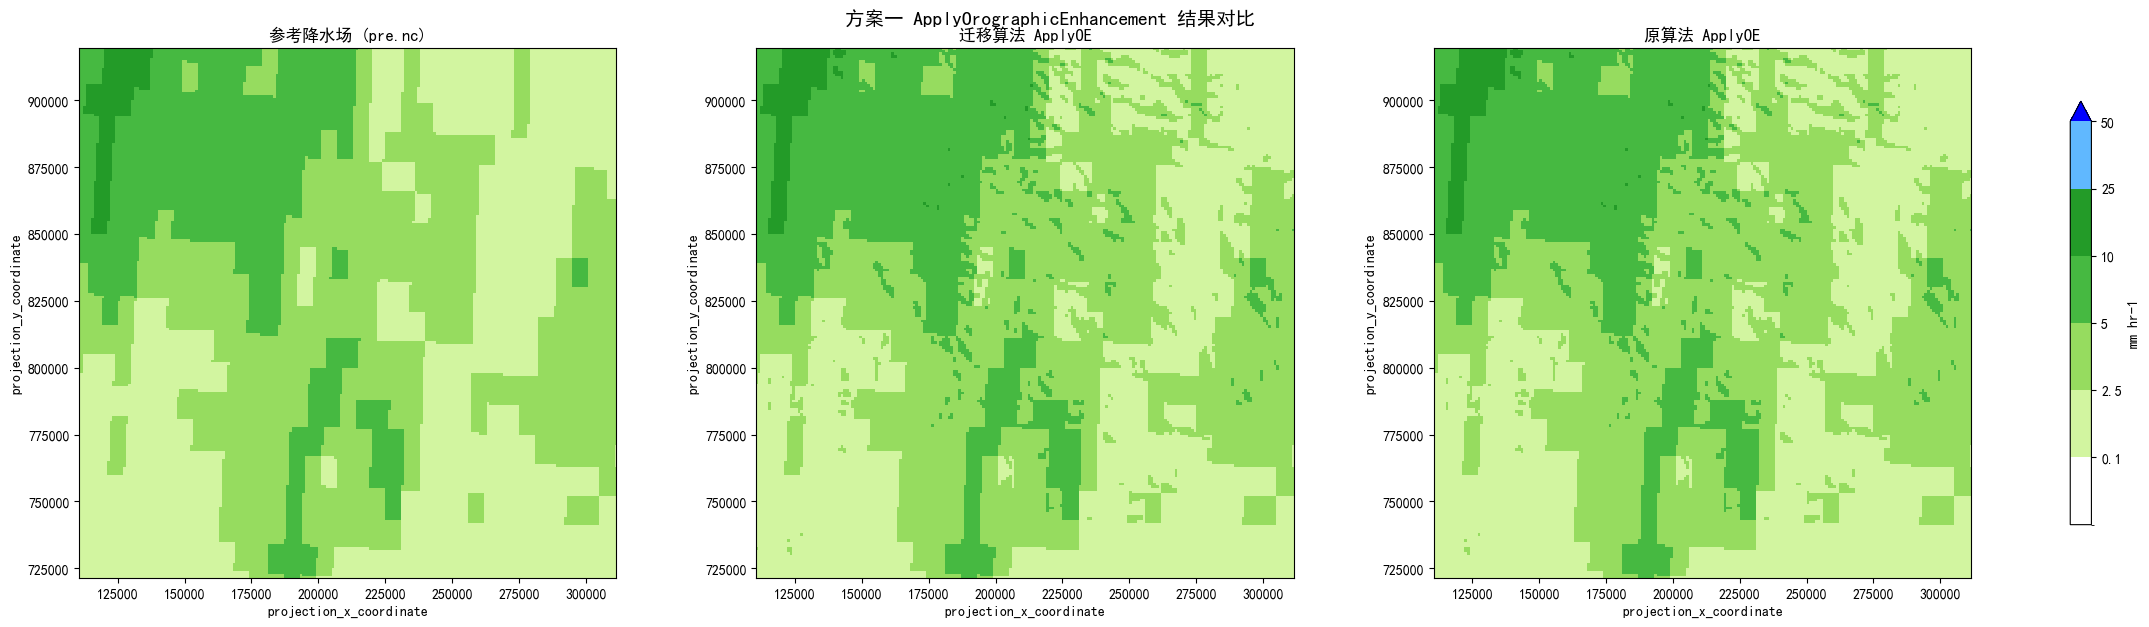

In [9]:
rainrate_path = DATA_DIR / "pre.nc"
oe_reference_path = DATA_DIR / "original_cli_result.nc"

precip_cube = squeeze_cube_to_projected_2d(
    harmonize_time_calendar_to_standard(iris.load_cube(rainrate_path))
)
oe_cube = squeeze_cube_to_projected_2d(
    harmonize_time_calendar_to_standard(iris.load_cube(oe_reference_path))
)
plugin_precip_cube = standardize_precip_cube_for_plugin(precip_cube, oe_cube)

original_apply_plugin = OriginalApplyOrographicEnhancement("add")
original_applied_cube = original_apply_plugin.process(
    iris.cube.CubeList([plugin_precip_cube]), oe_cube
)[0]

plot_rainrate_da = to_plot_2d(xr.DataArray.from_iris(plugin_precip_cube))
plot_original_applied_da = to_plot_2d(xr.DataArray.from_iris(original_applied_cube))

migrated_apply_plugin = MigratedApplyOrographicEnhancement("add")
precip_meb6d = _attach_grid_mapping_json(
    to_meb6d_for_apply(plot_rainrate_da, "lwe_precipitation_rate"),
    topography_meb,
)
oe_meb6d = _attach_grid_mapping_json(
    to_meb6d_for_apply(to_plot_2d(xr.DataArray.from_iris(oe_cube)), "orographic_enhancement"),
    topography_meb,
)
migrated_applied_meb = migrated_apply_plugin.process(precip_meb6d, oe_meb6d)

plot_migrated_applied_da = align_plot_to_reference(
    migrated_applied_meb.rename({"lat": "projection_y_coordinate", "lon": "projection_x_coordinate"}),
    plot_rainrate_da,
)
orig_for_align = plot_original_applied_da
if orig_for_align.dims == ("lat", "lon"):
    orig_for_align = orig_for_align.rename(
        {"lat": "projection_y_coordinate", "lon": "projection_x_coordinate"}
    )
plot_original_applied_da = align_plot_to_reference(orig_for_align, plot_rainrate_da)

fig, axes = plt.subplots(1, 3, figsize=(22, 6), constrained_layout=True)
fig.suptitle("方案一 ApplyOrographicEnhancement 结果对比", fontsize=14, y=1.02)
plot_ref = plot_rainrate_da
plot_field(axes[0], plot_rainrate_da, "参考降水场 (pre.nc)", reference=plot_ref)
mesh = plot_field(axes[1], plot_migrated_applied_da, "迁移算法 ApplyOE", reference=plot_ref)
plot_field(axes[2], plot_original_applied_da, "原算法 ApplyOE", reference=plot_ref)
add_precip_colorbar(fig, axes, mesh=mesh)
plt.show()


## CLI 应用示例与结果对比

CLI 从方案一写出目录 `cli_input/` 读取输入，结果写入 `cli_output/`。

示例脚本：`orographic_enhancement/cli/dsc_orographic_enhancement.py`


[方案一 插件-修改后CLI] mean_abs=0.00000000, max_abs=0.00000000, rmse=0.00000000
[方案一 插件-原算法CLI] mean_abs=0.00000000, max_abs=0.00000056, rmse=0.00000001
[方案一 修改后CLI-原算法CLI] mean_abs=0.00000000, max_abs=0.00000056, rmse=0.00000001


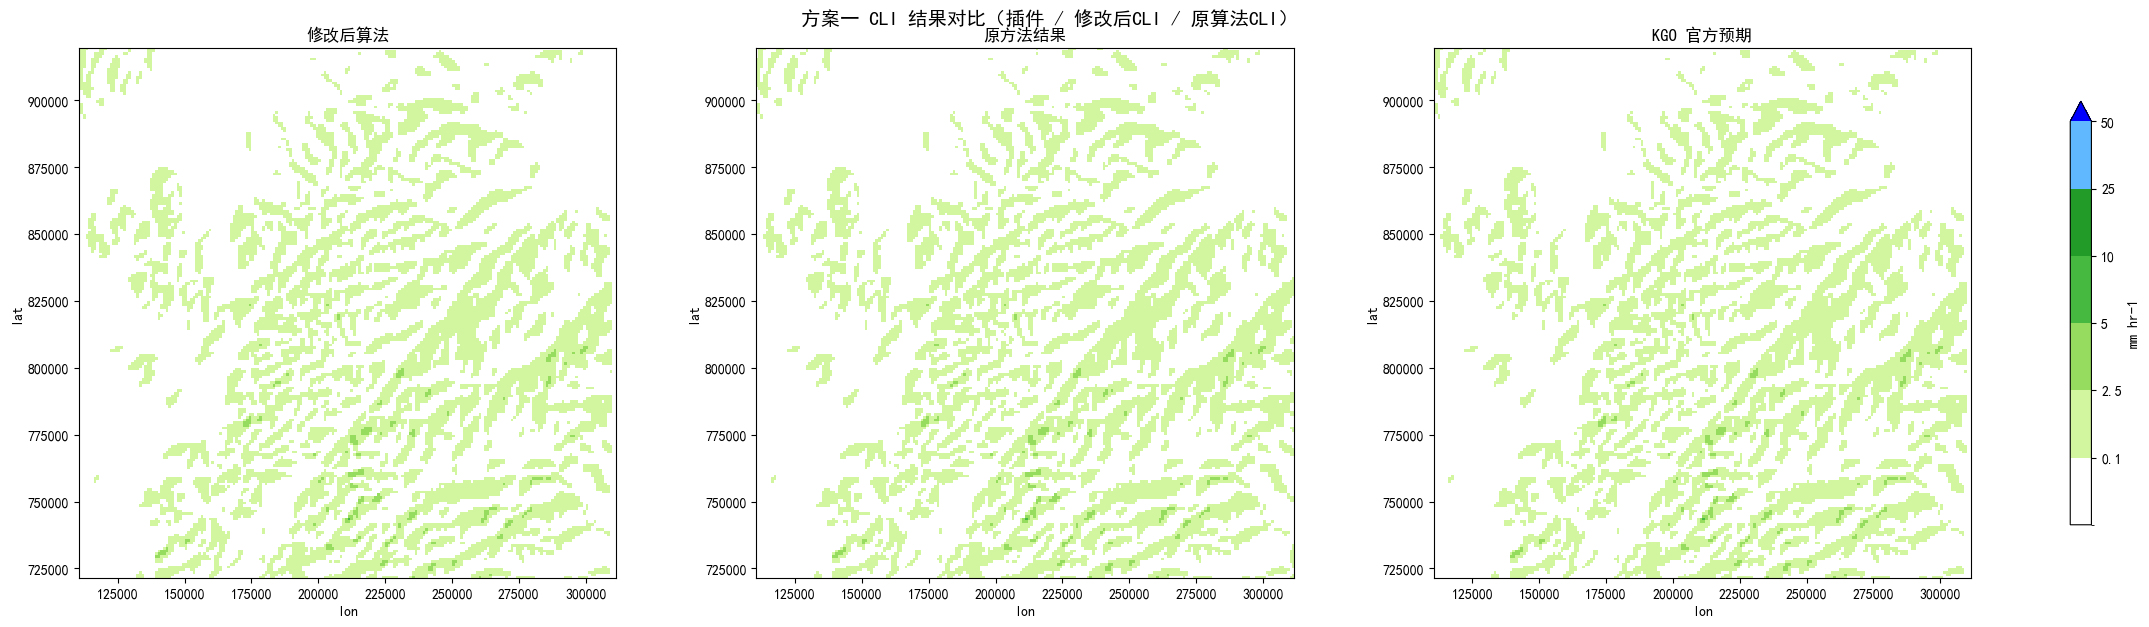

In [10]:
from orographic_enhancement.cli.dsc_orographic_enhancement import process as cli_process

CLI_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
cli_output_path = CLI_OUTPUT_DIR / "cli_test_result.nc"
cli_result_da = cli_process(
    str(CLI_INPUT_DIR / "temperature.nc"),
    str(CLI_INPUT_DIR / "humidity.nc"),
    str(CLI_INPUT_DIR / "pressure.nc"),
    str(CLI_INPUT_DIR / "wind_speed.nc"),
    str(CLI_INPUT_DIR / "wind_direction.nc"),
    str(CLI_INPUT_DIR / "orography_uk-standard_1km.nc"),
)
original_cli_da = load_primary_dataarray(DATA_DIR / "original_cli_result.nc", "orographic_enhancement")

compare_stats(migrated_s1, cli_result_da, "方案一 插件-修改后CLI")
compare_stats(migrated_s1, original_cli_da, "方案一 插件-原算法CLI")
compare_stats(cli_result_da, original_cli_da, "方案一 修改后CLI-原算法CLI")

plot_precip_triplet(
    migrated_s1,
    cli_result_da,
    original_cli_da,
    title="方案一 CLI 结果对比（插件 / 修改后CLI / 原算法CLI）",
)


## 方案二：经纬坐标输入

预处理阶段将投影坐标转为规则经纬网格并重采样；构造六维网格后调用 `meteva_base.reset` 使 lat 南→北、lon 西→东单调递增。

说明：原 IMPROVER iris 插件在纯经纬网格上会因坐标单位（degrees）与地形梯度计算（米制）不兼容而无法直接运行；方案二「原方法」对照采用官方 `original_algorithm_result.nc` 经相同重网格后的结果。

### 1. 数据预处理

In [11]:
import meteva_base as meb
from pyproj import CRS, Transformer
from scipy.interpolate import griddata

def _regularize_axis(values: np.ndarray) -> np.ndarray:
    arr = np.asarray(values, dtype=np.float64).reshape(-1)
    if arr.size < 2:
        return arr
    step = np.nanmedian(np.diff(arr))
    if not np.isfinite(step) or np.isclose(step, 0.0):
        return arr
    return arr[0] + step * np.arange(arr.size, dtype=np.float64)


def _regrid_projected_slice_to_latlon(arr2d: xr.DataArray, mapping_attrs: dict, *, method: str = "linear") -> xr.DataArray:
    y = np.asarray(arr2d.coords["projection_y_coordinate"].values, dtype=np.float64)
    x = np.asarray(arr2d.coords["projection_x_coordinate"].values, dtype=np.float64)
    yy, xx = np.meshgrid(y, x, indexing="ij")
    transformer = Transformer.from_crs(CRS.from_cf(mapping_attrs), CRS.from_epsg(4326), always_xy=True)
    lon2d_src, lat2d_src = transformer.transform(xx, yy)
    lat_1d = _regularize_axis(np.nanmean(lat2d_src, axis=1))
    lon_1d = _regularize_axis(np.nanmean(lon2d_src, axis=0))
    lat2d_tgt, lon2d_tgt = np.meshgrid(lat_1d, lon_1d, indexing="ij")
    src_points = np.column_stack([lat2d_src.ravel(), lon2d_src.ravel()])
    src_values = np.asarray(arr2d.values, dtype=np.float64).ravel()
    tgt_points = np.column_stack([lat2d_tgt.ravel(), lon2d_tgt.ravel()])
    interp_values = griddata(src_points, src_values, tgt_points, method=method)
    nan_mask = np.isnan(interp_values)
    if np.any(nan_mask):
        interp_nn = griddata(src_points, src_values, tgt_points, method="nearest")
        interp_values[nan_mask] = interp_nn[nan_mask]
    return xr.DataArray(
        interp_values.reshape(lat2d_tgt.shape).astype(np.float64),
        dims=("lat", "lon"),
        coords={"lat": lat_1d, "lon": lon_1d},
        name=str(arr2d.name or "field"),
        attrs={"units": str(arr2d.attrs.get("units", "1"))},
    )


def projected_da_to_regular_latlon(data: xr.DataArray, *, method: str = "linear") -> xr.DataArray:
    arr = data
    if "height" in arr.dims:
        arr = arr.rename({"height": "level"})
    for dim in list(arr.dims):
        if dim not in ("level", "projection_y_coordinate", "projection_x_coordinate", "lat", "lon"):
            arr = arr.isel({dim: 0}, drop=True)

    if not {"projection_y_coordinate", "projection_x_coordinate"}.issubset(set(arr.dims)):
        spatial = arr
        if spatial.dims != ("lat", "lon") and "level" in spatial.dims:
            spatial = spatial.transpose("level", "lat", "lon")
        elif spatial.dims != ("lat", "lon"):
            spatial = spatial.transpose("lat", "lon")
        return spatial

    mapping_json = arr.attrs.get("grid_mapping_attrs")
    if not isinstance(mapping_json, str) or not mapping_json.strip():
        raise ValueError("缺少 grid_mapping_attrs，无法做投影转经纬重网格。")
    mapping_attrs = json.loads(mapping_json)

    if "level" in arr.dims:
        level_slices = []
        for level_value in arr.coords["level"].values:
            slice_2d = arr.sel(level=level_value).drop_vars("level")
            level_slices.append(_regrid_projected_slice_to_latlon(slice_2d, mapping_attrs, method=method))
        stacked = xr.concat(level_slices, dim="level")
        stacked = stacked.assign_coords(level=arr.coords["level"].values.astype(np.float32))
        return stacked

    return _regrid_projected_slice_to_latlon(arr, mapping_attrs, method=method)


def _ensure_meb6d_spatial_order(data: xr.DataArray) -> xr.DataArray:
    """经 meb.reset 保证 lat 南→北、lon 西→东单调递增，并同步翻转数值。"""
    ordered = data.copy(deep=True)
    meb.reset(ordered)
    return ordered


def build_meb6d_from_latlon(nc_path: Path, var_name: str) -> xr.DataArray:
    spatial = projected_da_to_regular_latlon(load_primary_dataarray(nc_path, var_name))
    meb6d = _build_meb6d_from_spatial(
        spatial,
        name=var_name,
        extra_attrs={
            "grid_mapping_attrs": json.dumps(
                {"grid_mapping_name": "latitude_longitude"},
                ensure_ascii=False,
            ),
        },
    )
    return _ensure_meb6d_spatial_order(meb6d)


In [12]:
# 方案二：内存预处理（不写盘）
temperature_latlon = build_meb6d_from_latlon(DATA_DIR / "temperature.nc", "air_temperature")
humidity_latlon = build_meb6d_from_latlon(DATA_DIR / "humidity.nc", "relative_humidity")
pressure_latlon = build_meb6d_from_latlon(DATA_DIR / "pressure.nc", "air_pressure")
wind_speed_latlon = build_meb6d_from_latlon(DATA_DIR / "wind_speed.nc", "wind_speed")
wind_direction_latlon = build_meb6d_from_latlon(DATA_DIR / "wind_direction.nc", "wind_from_direction")
topography_latlon = build_meb6d_from_latlon(DATA_DIR / "orography_uk-standard_1km.nc", "surface_altitude")
kgo_latlon = build_meb6d_from_latlon(DATA_DIR / "kgo_hi_res.nc", "orographic_enhancement")
original_latlon = build_meb6d_from_latlon(DATA_DIR / "original_algorithm_result.nc", "orographic_enhancement")

print("方案二输入:", temperature_latlon.dims, temperature_latlon.shape)
print("方案二地形:", topography_latlon.dims, topography_latlon.shape)


方案二输入: ('member', 'level', 'time', 'dtime', 'lat', 'lon') (1, 5, 1, 1, 101, 101)
方案二地形: ('member', 'level', 'time', 'dtime', 'lat', 'lon') (1, 1, 1, 1, 199, 202)


### 2. MetaOrographicEnhancement

=== 方案二：MetaOrographicEnhancement ===
[方案二 修改后-KGO] mean_abs=0.00000001, max_abs=0.00000497, rmse=0.00000007
[方案二 修改后-原算法(重网格)] mean_abs=0.00000001, max_abs=0.00000497, rmse=0.00000007
[方案二 原算法(重网格)-KGO] mean_abs=0.00000000, max_abs=0.00000000, rmse=0.00000000


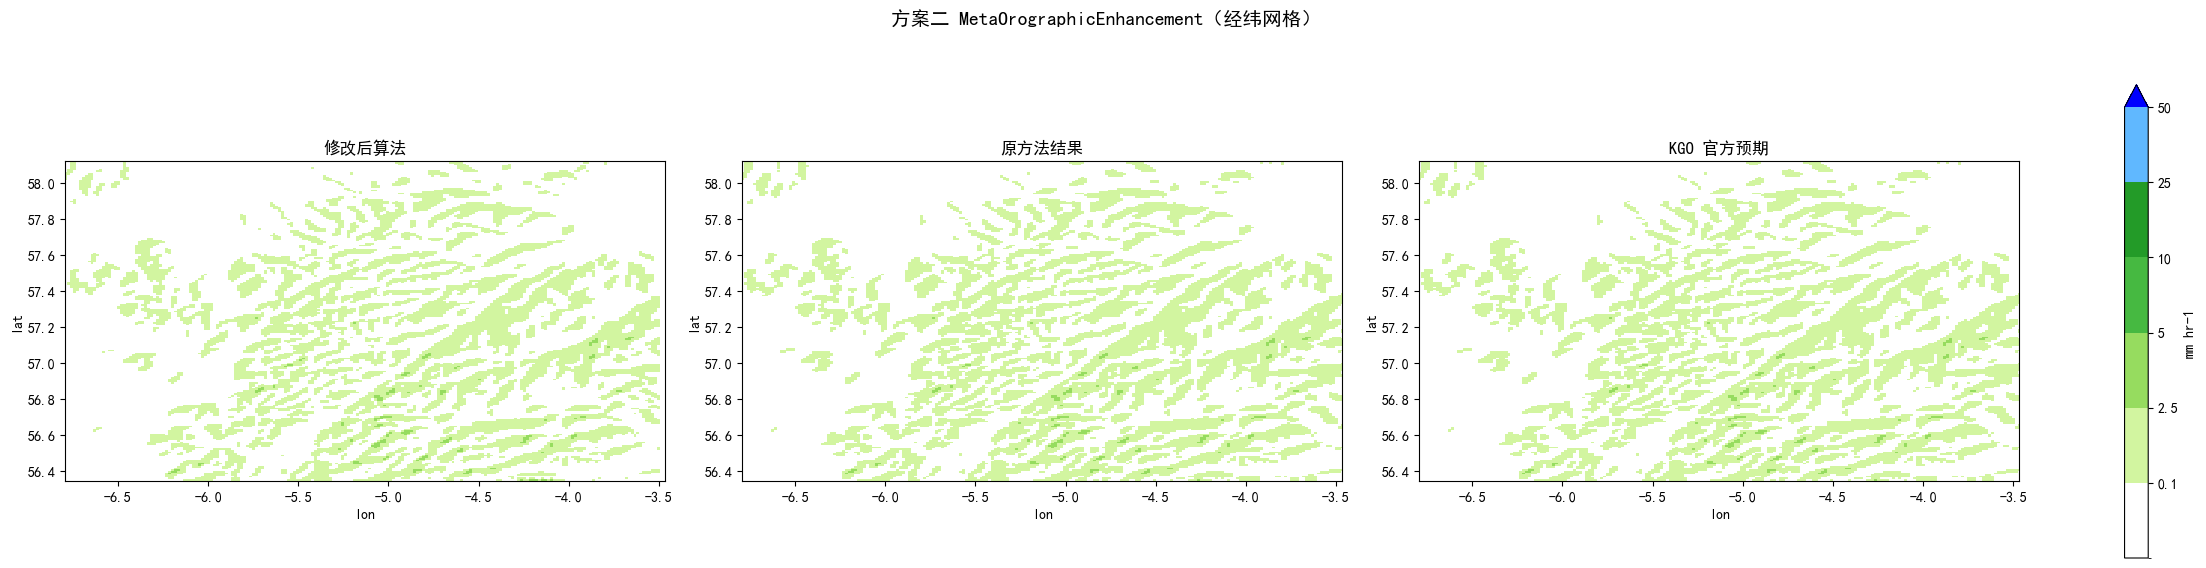

In [13]:
print("=== 方案二：MetaOrographicEnhancement ===")
plugin_s2 = MetaOrographicEnhancement()
migrated_s2 = plugin_s2(
    temperature_latlon,
    humidity_latlon,
    pressure_latlon,
    wind_speed_latlon,
    wind_direction_latlon,
    topography_latlon,
)
migrated_s2.name = "orographic_enhancement"

# 原 iris 插件无法在纯经纬网格上运行；使用相同重网格后的官方原算法结果作对照。
original_s2 = original_latlon

compare_stats(migrated_s2, kgo_latlon, "方案二 修改后-KGO")
compare_stats(migrated_s2, original_s2, "方案二 修改后-原算法(重网格)")
compare_stats(original_s2, kgo_latlon, "方案二 原算法(重网格)-KGO")
plot_precip_triplet(
    migrated_s2,
    kgo_latlon,
    original_s2,
    title="方案二 MetaOrographicEnhancement（经纬网格）",
)
